# Name: Fereshteh Sadeghi Naieni Fard

## PART IV: Build, Train, Test, and Evaluate ML Models

## 1. Load Data

#### 1.1. Import Neccessary Libraries and Modules

In [195]:
#Import pandas and numpy libraries
import pandas as pd
import numpy as np

#Import libraries and modules relevant to visualizations
from pandas.plotting import scatter_matrix
from matplotlib import pyplot

# Import Scikit learn train test split module
from sklearn.model_selection import train_test_split

#from sklearn module import Logistic regression and K nearest neighbors
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

#Import scikit learn module for k-fold cross validation, model evaluation and validation
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

#Import scikit learn module for classification report
from sklearn.metrics import classification_report

#### 1.2. Load the Dataset

With nearly 50,000 (fifty thousand) records, the dataset adult_salary.csv was collected with the following attributes in a census survey:  
1. Age: The age of the individual  
2. Emp_type: The type of employer the individual has, e.g. government, military, private, …   
3. Fnlwgt: An attribute used only for the census survey purpose- will be removed   
4. Education: The highest level of education achieved for that individual   
5. Education_num: the highest level of education of the individual in the numerical form   
6. Marital: The Marital status of the individual   
7. Occupation: The occupation of the individual   
8. Relationship: The most prominent relationship   
9. Race: The race of the individual   
10. Sex: The biological sex of the individual   
11. Capital_gain: Capital gains recorded   
12. Capital_loss: Capital losses recorded   
13. Weekly_hours: Number of working hours per week   
14. Country: The original country of the individual   
15. Income: Whether the person’s annual income is more than or less than and equal to 50,000.00   

In [196]:
#Specifu the path and name of the file
filename='C:/unt courses/Ph.D courses/INFO-ADTA 5340-Discovery and Learning with Big Data/Week8 Final Project/adult_salary.csv'

# Put the dataset in the pandas datafarme
df=pd.read_csv(filename, index_col= False)

# Remove Fnlwgt field
df=df.drop(columns=['Fnlwgt'])


In [197]:
# To avoid showing warning
import warnings
warnings.filterwarnings("ignore")

## 2. Preprocess the Dataset

In [199]:
#Class distribution Employment type
#Means how many records for each class 
print(df.groupby('Emp_type').size())

Emp_type
?                    2799
Federal-gov          1432
Local-gov            3136
Never-worked           10
Private             33906
Self-emp-inc         1695
Self-emp-not-inc     3862
State-gov            1981
Without-pay            21
dtype: int64


In [200]:
#Class distribution of Education
#Means how many records for each class
print(df.groupby('Education').size())

Education
10th             1389
11th             1812
12th              657
1st-4th           247
5th-6th           509
7th-8th           955
9th               756
Assoc-acdm       1601
Assoc-voc        2061
Bachelors        8025
Doctorate         594
HS-grad         15784
Masters          2657
Preschool          83
Prof-school       834
Some-college    10878
dtype: int64


In [201]:
#Class distribution of Marital status
#Means how many records for each class
print(df.groupby('Marital').size())

Marital
Divorced                  6633
Married-AF-spouse           37
Married-civ-spouse       22379
Married-spouse-absent      628
Never-married            16117
Separated                 1530
Widowed                   1518
dtype: int64


In [202]:
#Class distribution of Occupation status
#Means how many records for each class
print(df.groupby('Occupation').size())

Occupation
?                    2809
Adm-clerical         5611
Armed-Forces           15
Craft-repair         6112
Exec-managerial      6086
Farming-fishing      1490
Handlers-cleaners    2072
Machine-op-inspct    3022
Other-service        4923
Priv-house-serv       242
Prof-specialty       6172
Protective-serv       983
Sales                5504
Tech-support         1446
Transport-moving     2355
dtype: int64


In [203]:
#Class distribution of Relationship
#Means how many records for each class
print(df.groupby('Relationship').size())

Relationship
Husband           19716
Not-in-family     12583
Other-relative     1506
Own-child          7581
Unmarried          5125
Wife               2331
dtype: int64


In [204]:
#Class distribution of Race
#Means how many records for each class
print(df.groupby('Race').size())

Race
Amer-Indian-Eskimo      470
Asian-Pac-Islander     1519
Black                  4685
Other                   406
White                 41762
dtype: int64


In [205]:
#Class distribution of Sex
#Means how many records for each class
print(df.groupby('Sex').size())

Sex
Female    16192
Male      32650
dtype: int64


In [206]:
#Class distribution of Country
#Means how many records for each class
print(df.groupby('Country').size())

Country
?                               857
Cambodia                         28
Canada                          182
China                           122
Columbia                         85
Cuba                            138
Dominican-Republic              103
Ecuador                          45
El-Salvador                     155
England                         127
France                           38
Germany                         206
Greece                           49
Guatemala                        88
Haiti                            75
Holand-Netherlands                1
Honduras                         20
Hong                             30
Hungary                          19
India                           151
Iran                             59
Ireland                          37
Italy                           105
Jamaica                         106
Japan                            92
Laos                             23
Mexico                          951
Nicaragua           

In [207]:
#Class distribution of Income
#Means how many records for each class
print(df.groupby('Income').size())

Income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
dtype: int64


#### Comments on the Dataset:
1-Age include all numeric values and does not need any preprocessing    
2-Emp_type is the type of employmeny which include different valid types: Federal-gov,Local-gov,Never-worked,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Without-pay
However it also include ? that should be included in the null values.       
3- Fnlwgt includes all valid numeric values ranges between 19214 to 1184622 and does not need any preprocessing.    
4- Education field include different levels: 10th, 11th, 12th, 1st-4th, 5th-6th, 7th-8th, 9th, Assoc-acdm, Assoc-voc, Bachelors, Doctorate, HS-grad, Masters, Preschool, Prof-school, Some-college.     
5- Marital field has also valid values including:  Divorced, Married-AF-spouse, Married-civ-spouse, Married-spouse-absent, Never-married, Separated, Widowed.    
6- Occupation field has both invalid and valid types. It includes: Adm-clerical, Armed-Forces, Craft-repair, Exec-managerial, Farming-fishing, Handlers-cleaners, Machine-op-inspct, Other-service, Priv-house-serv,, Prof-specialty,  Protective-serv, Sales,  Tech-support,  Transport-moving.     
However, it also has invalid data ? that should be preprocessed before model fitting.    
7- The Relationship field includes these types:Husband, Not-in-family, Other-relative, Own-child, Unmarried, Wife.    
8- Race also has valid types including:Amer-Indian-Eskimo, Asian-Pac-Islander, Black, Other, White.    
9- Sex has two types of Male (0) and Female(1).    
10- The field Capital_gain ranges from 0 to 99999 and all are numeric without any invalid data.    
11- The field Captal_loss also ranges from 0 to 4356 and all are numeric without need to preprocessing.    
12- The field weekly ranges from 1 to 99 and all are numeric without any invalid value.    
13- The field country includes the names of 41 county. However, it includes also ? that should be gone through preprocessing.   
14- In the Field Income some values have '.' at the end that will be removed in the preprocessing

#### Note:
So, field Emp_type, Occupation, and Country has ? values that should be converted to Nan and finally removed from the dataset.    

In [208]:
# Replace ? with Nan to teat them as missing values in those three columns
df['Emp_type']=df['Emp_type'].str.strip().replace('?',np.nan)
df['Occupation']=df['Occupation'].str.strip().replace('?',np.nan)
df['Country']=df['Country'].str.strip().replace('?',np.nan)

In [209]:
#Remove '.' from the end of income
df['Income'] = df['Income'].str.rstrip('.')

In [210]:
# Print count of null values
print(df.isnull().sum())

Age                 0
Emp_type         2799
Education           0
Education_num       0
Marital             0
Occupation       2809
Relationship        0
Race                0
Sex                 0
Capital_gain        0
Capital_loss        0
weekly_hours        0
Country           857
Income              0
dtype: int64


In [211]:
#Remove the records contain null values from the dataset
df=df.dropna()

In [212]:
df.to_csv('C:/unt courses/Ph.D courses/INFO-ADTA 5340-Discovery and Learning with Big Data/Week8 Final Project/adult_salary_clean.csv',index=False)

## 3.Perform Exploratory Data Analysis

In [213]:
#Get the dimensions or shape of the dataset
print(df.shape)

(45222, 14)


In [214]:
#Get the data types of all the attributes
print(df.dtypes)

Age               int64
Emp_type         object
Education        object
Education_num     int64
Marital          object
Occupation       object
Relationship     object
Race             object
Sex              object
Capital_gain      int64
Capital_loss      int64
weekly_hours      int64
Country          object
Income           object
dtype: object


In [215]:
#Get the data types of all the varaibles of the dataset
print(df.head(5))

   Age          Emp_type   Education  Education_num              Marital  \
0   39         State-gov   Bachelors             13        Never-married   
1   50  Self-emp-not-inc   Bachelors             13   Married-civ-spouse   
2   38           Private     HS-grad              9             Divorced   
3   53           Private        11th              7   Married-civ-spouse   
4   28           Private   Bachelors             13   Married-civ-spouse   

          Occupation    Relationship    Race      Sex  Capital_gain  \
0       Adm-clerical   Not-in-family   White     Male          2174   
1    Exec-managerial         Husband   White     Male             0   
2  Handlers-cleaners   Not-in-family   White     Male             0   
3  Handlers-cleaners         Husband   Black     Male             0   
4     Prof-specialty            Wife   Black   Female             0   

   Capital_loss  weekly_hours        Country  Income  
0             0            40  United-States   <=50K  
1     

In [216]:
#Get the summary statistics of the numeric variables of the dataset
print(df.describe())

                Age  Education_num  Capital_gain  Capital_loss  weekly_hours
count  45222.000000   45222.000000  45222.000000  45222.000000  45222.000000
mean      38.547941      10.118460   1101.430344     88.595418     40.938017
std       13.217870       2.552881   7506.430084    404.956092     12.007508
min       17.000000       1.000000      0.000000      0.000000      1.000000
25%       28.000000       9.000000      0.000000      0.000000     40.000000
50%       37.000000      10.000000      0.000000      0.000000     40.000000
75%       47.000000      13.000000      0.000000      0.000000     45.000000
max       90.000000      16.000000  99999.000000   4356.000000     99.000000


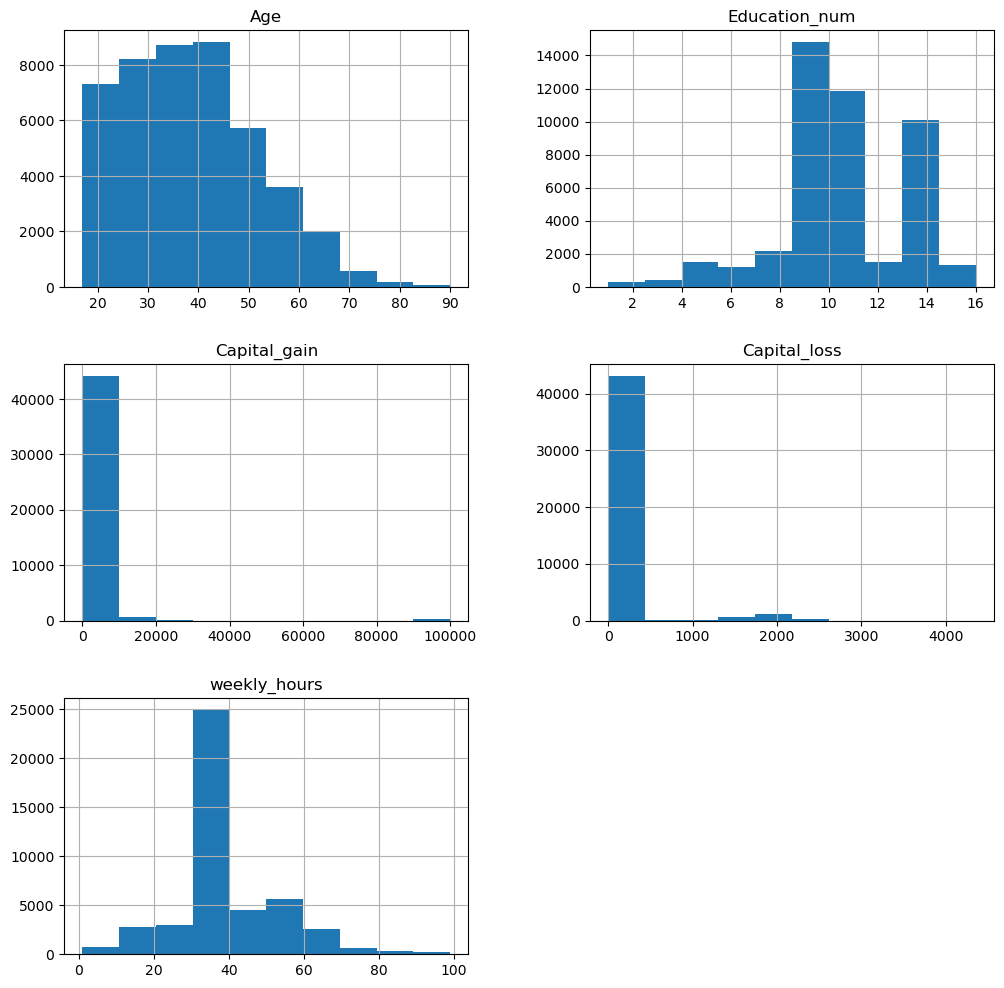

In [217]:
#Plot histogram for each numeric variable of the dataset
df.hist(figsize=(12,12))
pyplot.show()

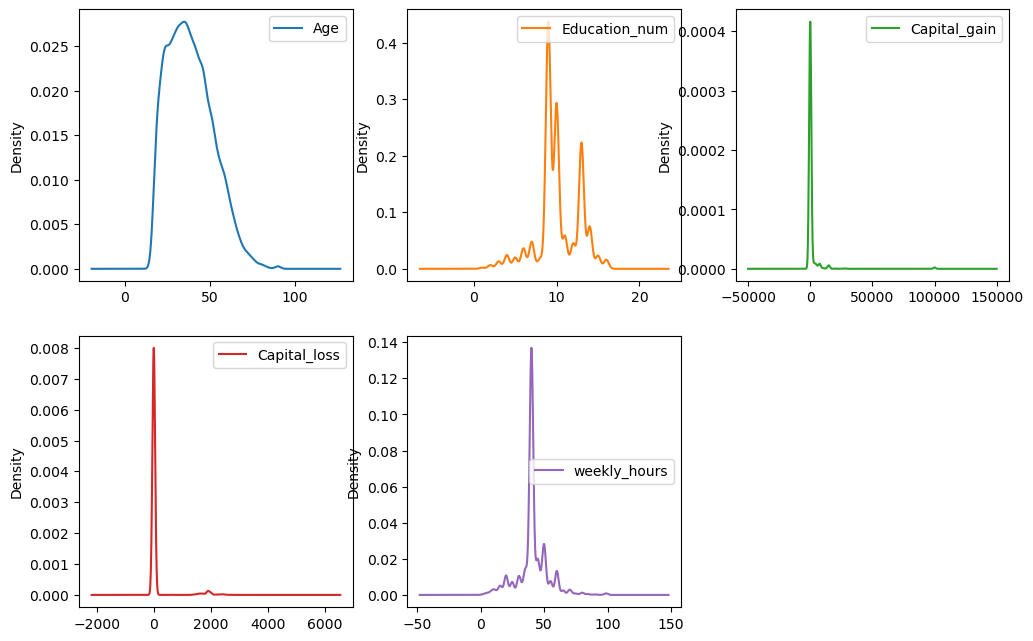

In [218]:
#Plot density plots for each numeric variable of the dataset
df.plot(kind='density',subplots=True,layout=(3,3),sharex=False, legend=True, figsize=(12,12))
pyplot.show()

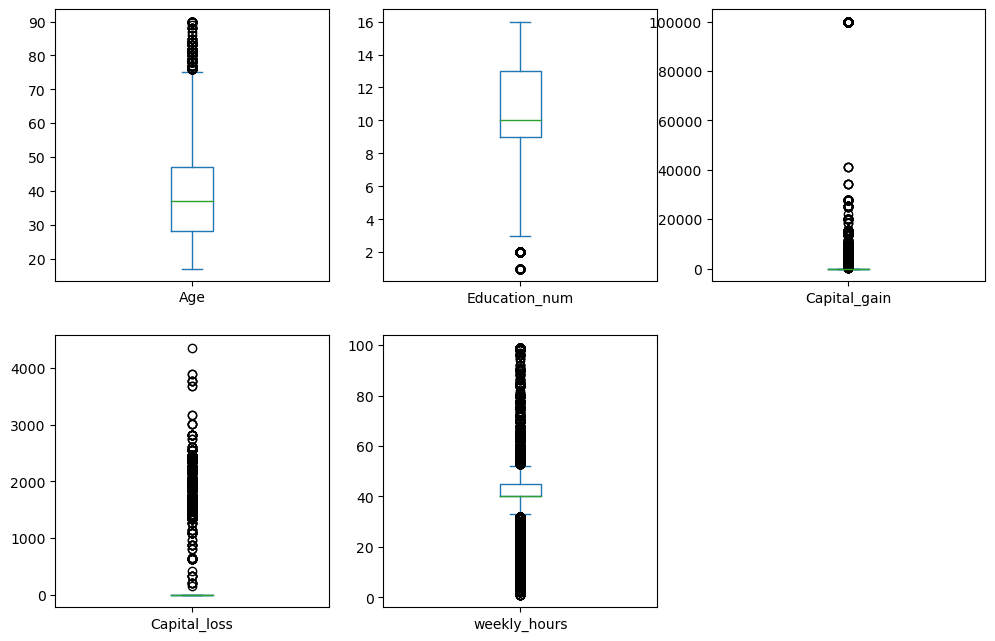

In [219]:
#Plot Boxplots for each numeric variable of the dataset
df.plot(kind='box',subplots=True, sharex=False,sharey=False, layout=(3,3), figsize=(12,12))
pyplot.show()

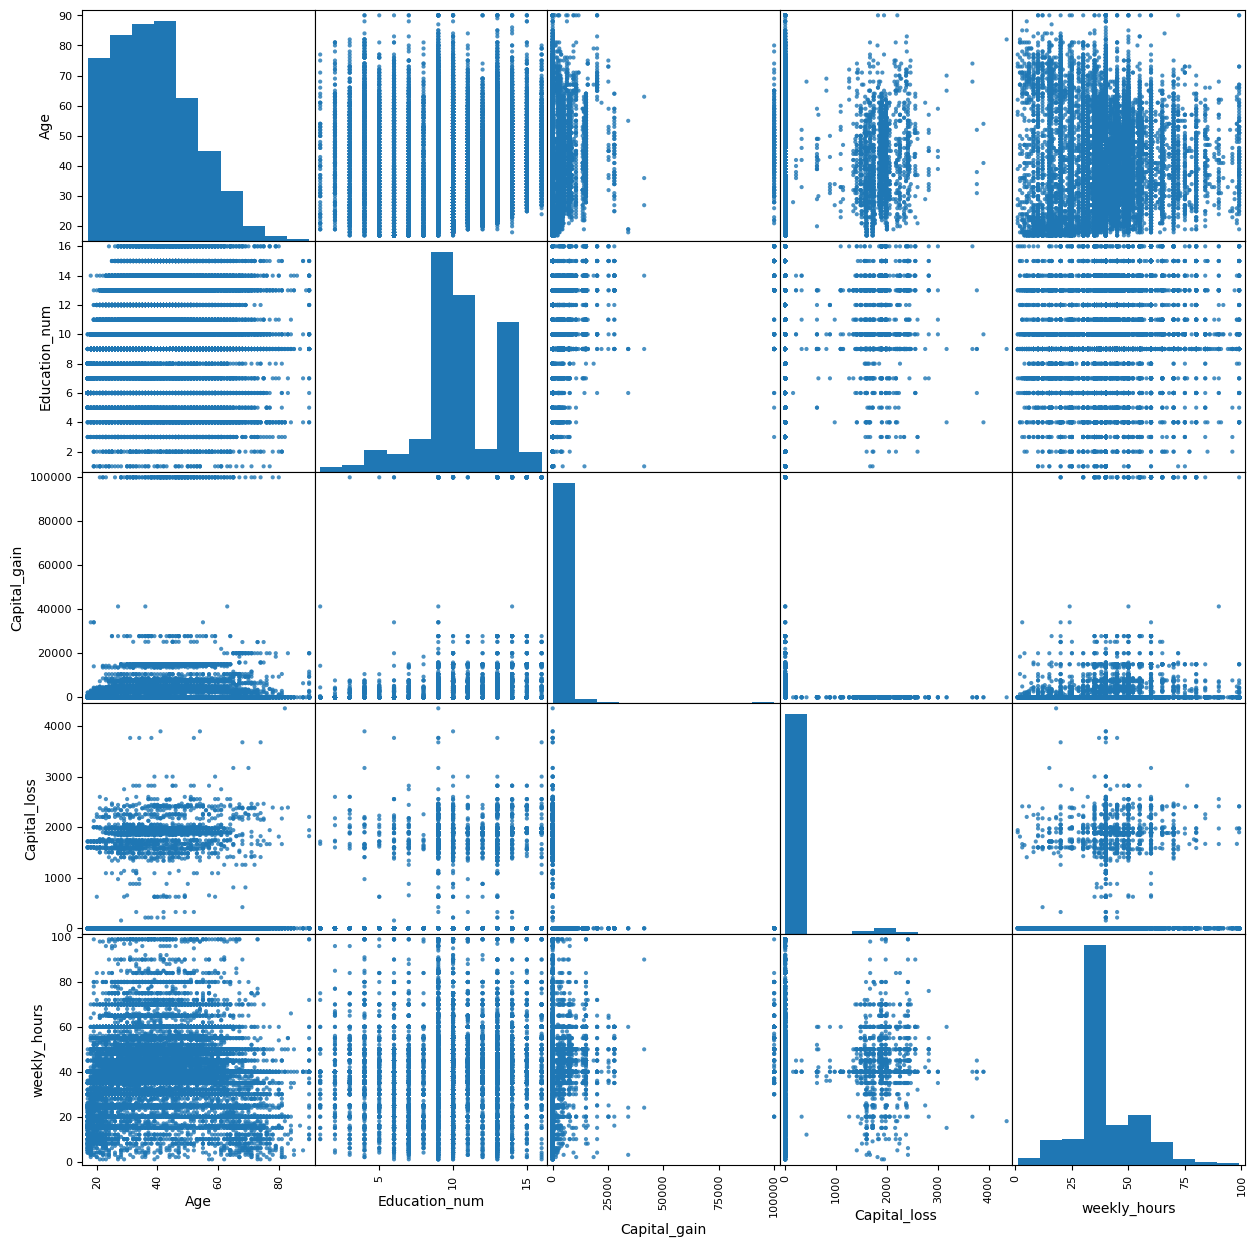

In [220]:
#Scatter plot matrix
scatter_matrix(df, alpha=0.8, figsize=(15,15))
pyplot.show()

## 4. Split the Dataset into Input/Output

In [221]:
#Convert category labels to numeric labales by setting the predefined orders for employment type
df['Emp_type'] = df['Emp_type'].str.strip()
df['Emp_type'] = pd.Categorical(df['Emp_type'], categories=['Federal-gov','Local-gov','Never-worked','Private','Self-emp-inc','Self-emp-not-inc','State-gov','Without-pay'], ordered=True)
df['Emp_type'] = df['Emp_type'].cat.codes  # Federal-gov=0 ,Local-gov=1 ,Never-worked=2 ,Private=3 ,Self-emp-inc=4 ,Self-emp-not-inc=5 ,State-gov=6 ,Without-pay=7

In [222]:
#Convert category labels to numeric labales by setting the predefined orders for education levels
df['Education'] = df['Education'].str.strip()
df['Education'] = pd.Categorical(
    df['Education'],
    categories=[
        'Preschool',
        '1st-4th',
        '5th-6th',
        '7th-8th',
        '9th',
        '10th',
        '11th',
        '12th',
        'HS-grad',
        'Some-college',
        'Assoc-voc',
        'Assoc-acdm',
        'Bachelors',
        'Masters',
        'Prof-school',
        'Doctorate'
    ],
    ordered=True
)

df['Education'] = df['Education'].cat.codes # Preschool=0, 1st-4th=1, 5th-6th=2, 7th-8th=3, 9th=4, 10th=5, 11th=6, 12th=7,


In [223]:
#Convert category labels to numeric labales by setting the predefined orders for marital status
df['Marital'] = df['Marital'].str.strip()
df['Marital'] = pd.Categorical(df['Marital'], categories=['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed'], ordered=True)
df['Marital'] = df['Marital'].cat.codes  # Divorced=0, Married-AF-spouse=1, Married-civ-spouse=2, Married-spouse-absent=3, Never-married=4, Separated=5, Widowed=6

In [224]:
#Convert category labels to numeric labales by setting the predefined orders for occupation
df['Occupation'] = df['Occupation'].str.strip()
df['Occupation'] = pd.Categorical(df['Occupation'], categories=['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service','Priv-house-serv','Prof-specialty','Protective-serv','Sales','Tech-support','Transport-moving'], ordered=True)
df['Occupation'] = df['Occupation'].cat.codes  # Adm-clerical=0, Armed-Forces=1, Craft-repair=2, Exec-managerial=3, Farming-fishing=4, Handlers-cleaners=5, Machine-op-inspct=6, Other-service=7, Priv-house-serv=8, Prof-specialty=9,  Protective-serv=9, Sales=10,  Tech-support=11,  Transport-moving=12

In [225]:
#Convert category labels to numeric labales by setting the predefined orders for relationship
df['Relationship'] = df['Relationship'].str.strip()
df['Relationship'] = pd.Categorical(df['Relationship'], categories=['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife'], ordered=True)
df['Relationship'] = df['Relationship'].cat.codes  # Husband=0, Not-in-family=1, Other-relative=2, Own-child=3, Unmarried=4, Wife=5

In [226]:
#Convert category labels to numeric labales by setting the predefined orders for race
df['Race'] = df['Race'].str.strip()
df['Race'] = pd.Categorical(df['Race'], categories=['White','Black','Amer-Indian-Eskimo','Asian-Pac-Islander','Other'], ordered=True)
df['Race'] = df['Race'].cat.codes  # White=0,Black=1,Amer-Indian-Eskimo=2,Asian-Pac-Islander=3,Other=4

In [227]:
#Convert category labels to numeric labales by setting the predefined orders for sex
df['Sex'] = df['Sex'].str.strip()
df['Sex'] = pd.Categorical(df['Sex'], categories=['Male','Female'], ordered=True)
df['Sex'] = df['Sex'].cat.codes  # Male=0, Female=1

In [228]:
#Convert category labels to numeric labales by setting the predefined orders for country
df['Country'] = df['Country'].str.strip()
df['Country'] = pd.Categorical(df['Country'], categories=['Cambodia','Canada','China','Columbia','Cuba','Dominican-Republic','Ecuador','El-Salvador','England','France','Germany','Greece','Guatemala','Haiti','Holand-Netherlands','Honduras','Hong','Hungary','India','Iran','Ireland','Italy','Jamaica','Japan','Laos','Mexico','Nicaragua','Outlying-US(Guam-USVI-etc)','Peru','Philippines','Poland','Portugal','Puerto-Rico','Scotland','South','Taiwan','Thailand','Trinadad&Tobago','United-States','Vietnam','Yugoslavia'
], ordered=True)
df['Country'] = df['Country'].cat.codes  # 'Cambodia'=0, 'Canada'=1, 'China'=2, 'Columbia'=3, 'Cuba'=4, 'Dominican-Republic'=5, 'Ecuador'=6, 'El-Salvador'=7, 'England'=8, 'France'=9, 'Germany'=10, 'Greece'=11, 'Guatemala'=12, 'Haiti'=13, 'Holand-Netherlands'=14, 'Honduras'=15, 'Hong'=16, 'Hungary'=17, 'India'=18, 'Iran'=19, 'Ireland'=20, 'Italy'=21, 'Jamaica'=22, 'Japan'=23, 'Laos'=24, 'Mexico'=25, 'Nicaragua'=26, 'Outlying-US(Guam-USVI-etc)'=27, 'Peru'=28, 'Philippines'=29, 'Poland'=30, 'Portugal'=31, 'Puerto-Rico'=32, 'Scotland'=33, 'South'=34, 'Taiwan'=35, 'Thailand'=36, 'Trinadad&Tobago'=37, 'United-States'=38, 'Vietnam'=39, 'Yugoslavia'=40

In [229]:
#Split the dataset into input and output
# put the dataframe in the numpy array
array=df.values

#Split the dataset into the array of predictors and target 
# The predictors include all columns except the income
x=array[:,:-1]

#The target is the last field
y=array[:,-1]

## 5. Split the dataset into train/test datasets

In [230]:
#split the dataset into train and test datasets
# A subset of data with 67% data will be train set and test set includes 33% of the data
test_size=0.33

#Use seed for randomization
seed=7

#split the dataset into train and test datasets
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=test_size, random_state=seed)

## 6. Build the Models

In [231]:
#Specify the model
model_LR=LogisticRegression()

#Train the model with x_train set
model_LR.fit(x_train,y_train)

#Predict the y_test by using the model and report the results and evaluate the performance of the model
predicted_LR=model_LR.predict(x_test)
report_LR=classification_report(y_test,predicted_LR)
print(report_LR)

              precision    recall  f1-score   support

       <=50K       0.81      0.95      0.87     11168
        >50K       0.69      0.35      0.47      3756

    accuracy                           0.80     14924
   macro avg       0.75      0.65      0.67     14924
weighted avg       0.78      0.80      0.77     14924



In [232]:
#Build the model
model_KNN=KNeighborsClassifier(n_neighbors=7)

#Train the model using training subdataset
model_KNN.fit(x_train, y_train)

#Print the classification report
predicted_KNN=model_KNN.predict(x_test)

#Classification report: Compare the prediction based on x_test with y_test
report_KNN=classification_report(y_test, predicted_KNN)
print(report_KNN)

              precision    recall  f1-score   support

       <=50K       0.88      0.91      0.89     11168
        >50K       0.69      0.63      0.66      3756

    accuracy                           0.84     14924
   macro avg       0.79      0.77      0.78     14924
weighted avg       0.83      0.84      0.83     14924



#### Prediction1:    
Age: 42   
Emp_type: Private =3    
Education: Bachelors=12    
Education_num: 13   
Marital: Married-civ-spouse =2  
Occupation: Exec-managerial =3     
Relationship: Husband=0      
Race: White=0   
Sex: Male =0
Capital_gain: 5178   
Capital_loss: 0  
Weekly_hours: 40   
Country: United-States=38   

In [233]:
#prediction1
model_KNN.predict([[42,3,12,13,2,3,0,0,0,5178,0,40,38]])

array([' >50K'], dtype=object)

In [234]:
#prediction1
model_LR.predict([[42,3,12,13,2,3,0,0,0,5178,0,40,38]])

array([' >50K'], dtype=object)

#### Prediction2:   
Age: 40     
Emp_type: Private =3      
Education: Doctorate=15     
Education_num: 16     
Marital: Married-civ-spouse =2  
Occupation: Prof-specialty =9      
Relationship: Husband=0        
Race: Black=1     
Sex: Woman =1    
Capital_gain: 0     
Capital_loss: 0    
Weekly_hours: 60     
Country: United-States=38  

In [235]:
#prediction1
model_KNN.predict([[40,3,15,16,2,9,0,1,1,0,0,60,38]])

array([' >50K'], dtype=object)

In [236]:
#prediction2
model_LR.predict([[40,3,15,16,2,9,0,1,1,0,0,60,38]])

array([' >50K'], dtype=object)

## 7. Cross Validation

In [237]:
#Evaluate the algorithm of logistic regression
#Specify the number of splits
n_splits=10

#Fix the random seed value
#We should use the same seed so that same subdatasets will be obtianed
# For each time the process is repeated
seed=7


# Split the whole data into folds
kfold=KFold(n_splits=n_splits,shuffle=True, random_state=seed)

#For KNN we can use accuracy level to evaluate the model/algorithm
scoring='accuracy'

#Train the model and run KFold cross validation to validate or evaluate
results_LR=cross_val_score(model_LR,x,y,cv=kfold,scoring=scoring)

#Print out the evaluation results . The result is the average of all results obtained from the K fold cross validation
print("Acurracy:%.3f(%.3f)"%(results_LR.mean(),results_LR.std()))

Acurracy:0.804(0.006)


In [238]:
#Evaluate the algorithm of k nearest neighbors
#Specify the number of splits
n_splits=10

#Fix the random seed value
#We should use the same seed so that same subdatasets will be obtianed
# For each time the process is repeated
seed=7


# Split the whole data into folds
kfold=KFold(n_splits=n_splits,shuffle=True, random_state=seed)

#For KNN we can use accuracy level to evaluate the model/algorithm
scoring='accuracy'

#Train the model and run KFold cross validation to validate or evaluate
results_KNN=cross_val_score(model_KNN,x,y,cv=kfold,scoring=scoring)

#Print out the evaluation results . The result is the average of all results obtained from the K fold cross validation
print("Acurracy:%.3f(%.3f)"%(results_KNN.mean(),results_KNN.std()))

Acurracy:0.844(0.005)


## 8. Comparisons of the Models

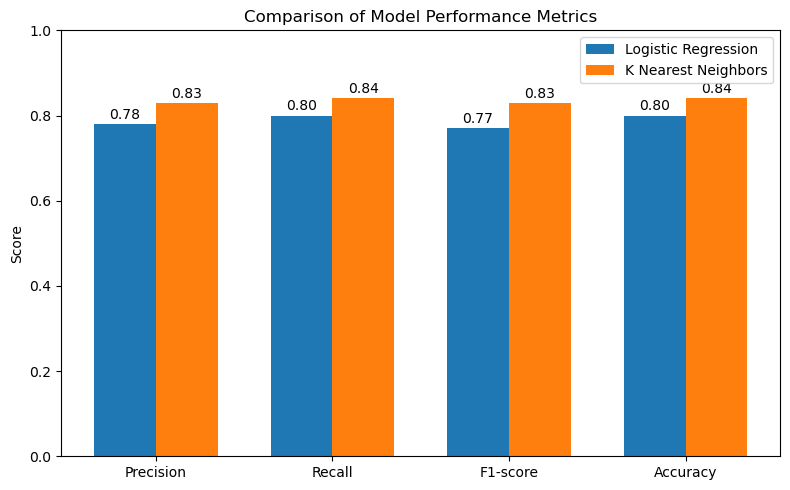

In [239]:
#Creating the comparison bar charts for comparing metrics of two models
# Metrics for the two models
metrics = ['Precision', 'Recall', 'F1-score', 'Accuracy']

model1 = [0.78, 0.80, 0.77, 0.80]
model2 = [0.83, 0.84, 0.83, 0.84]

x = np.arange(len(metrics))
width = 0.35  # width of the bars

pyplot.figure(figsize=(8,5))
bars1 = pyplot.bar(x - width/2, model1, width, label='Logistic Regression')
bars2 = pyplot.bar(x + width/2, model2, width, label='K Nearest Neighbors')

# Add labels above bars
for bars in [bars1, bars2]:
    for bar in bars:
        yval = bar.get_height()
        pyplot.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.2f}',
                 ha='center', va='bottom', fontsize=10)

pyplot.xticks(x, metrics)
pyplot.ylim(0, 1)
pyplot.ylabel('Score')
pyplot.title('Comparison of Model Performance Metrics')
pyplot.legend()
pyplot.tight_layout()
pyplot.show()
